In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load market data for each symbol (example with 7 symbols)
symbols = ['2yr', '3yr', '5yr', '7yr', '10yr', '20yr', '30yr']
market_data = {}
for symbol in symbols:
    market_data[symbol] = pd.read_csv(f'{symbol}_combined_result.csv')

# Load trading data (with mixed symbols)
trading_data = pd.read_parquet('merged_r8fin_trades.parquet')

In [3]:
trading_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label'],
      dtype='object')

In [4]:
trading_data['instrument']

0              Z XM ROLL 1.8% FRONTS
1              Z XM ROLL 1.8% FRONTS
2              Z XM ROLL 1.8% FRONTS
3              Z XM ROLL 1.8% FRONTS
4              Z XM ROLL 1.8% FRONTS
                     ...            
5923554    CT5-TYZ4-CT10 (TYFLY) (Y)
5923555    CT5-TYZ4-CT10 (TYFLY) (Y)
5923556    CT5-TYZ4-CT10 (TYFLY) (Y)
5923557    CT5-TYZ4-CT10 (TYFLY) (Y)
5923558                 CT2-CT30 (Y)
Name: instrument, Length: 5923559, dtype: object

In [5]:
trading_data['is_aggressive'].unique()

array([nan,  0.,  1.])

In [6]:
trading_data['side'].unique()

array(['B', 'S'], dtype=object)

In [7]:
trading_data['symbol'].unique()

array(['SFE XMU4-XMZ4', 'SFE XMZ4', 'SFE YMZ4', 'SFE YMU4-YMZ4',
       'CBOT TYZ4', 'CBOT WNZ4', 'CBOT TUZ4', 'CME SFRZ5', 'CBOT FFV4',
       'EUREX UBZ4', 'EUREX OEZ4', 'CBOT FFN5-FFQ5', 'EUREX DUZ4',
       'IFLL ERZ4', 'ME CVZ4', 'ME CNZ4', 'ME CORH5', 'ME CORZ4',
       'ME CORZ5', 'ME CORU5', 'ME CORH6', 'ME CORM5', 'ME XQZ4',
       'CME SFRH5', 'CME SERV4-FFV4', 'CBOT FFX4', 'CBOT FFU4',
       'CBOT USZ4', 'CBOT UXYZ4', 'CBOT FVZ4', 'ME CORM6',
       'CME SFR:AB 02Y Z4', 'CME SFRZ4', 'CME SERU4', 'EUREX IKZ4',
       'EUREX RXZ4', 'CME SERV4', 'CME SERX4', 'IFLL ERU5', 'EUREX OATZ4',
       'EUREX BTSZ4', 'CME SFR:BF M6-U6-Z6', 'CME SERF5-FFF5',
       'CME SFRZ4-SFRZ5', 'CME SFR:AB 01Y Z4', 'CME SFR:AB 01Y Z7',
       'CME SFR:AB 01Y Z6', 'CME SFR:AB 01Y Z5', 'CME SFRU4', 'CME SFRZ8',
       'CME SFRH9', 'CME SFRM9', 'CME SFR:AB 05Y Z4', 'CME SFR:AB 03Y Z4',
       'CME SFRM5', 'CME SFRU5', 'CME SFRU6', 'CME SFRM6', 'IFLL G Z4',
       'CME SFRH8', 'CME SFRZ6', 'CME SFRH6',

# how many trades for each symbol

In [8]:
# Count the number of trades for each symbol
symbol_trade_counts = trading_data['symbol'].value_counts()
print(symbol_trade_counts.head(40))

symbol
5 Year                 535599
10 Year                387564
CME SFR:AB 03Y Z4      292452
CME SFR:AB 03Y U4      270612
2 Year                 252525
3 Year                 215598
CME SFR:AB 02Y U4      208608
CME SFR:AB 02Y Z4      201048
30 Year                177066
7 Year                 173103
CBOT TUZ4              162625
CBOT FVZ4              157161
CME SFR:AB 05Y Z4      154860
CBOT TYZ4              125117
CME SFR:AB 05Y U4      118780
CBOT UXYZ4              92436
EUREX RXZ4              83367
20 Year                 76921
CBOT WNZ4               75073
CBOT FVU4               70188
CBOT TUU4               70158
CME SFR:AB 01Y Z4       68044
CBOT USZ4               58088
CME SFR:AB 01Y U4       57790
CME SFR:AB 01Y U5       53626
CBOT TYU4               53218
CME SFR:AB 01Y Z5       48488
EUREX DUZ4              47386
IFLL SFI: BNDLY2 U4     44904
EUREX OEZ4              36107
CBOT UXYU4              33791
CBOT WNU4               31958
CME SFRZ5               31284
CME

In [9]:
specific_symbols = ['20 Year O1', '10 Year O1', '30 Year O1', '7 Year O1', '5 Year O1', '3 Year O1', '7 Year O2']

# Get the trade counts for the specific symbols
specific_symbol_counts = symbol_trade_counts[symbol_trade_counts.index.isin(specific_symbols)]
print(specific_symbol_counts)

symbol
10 Year O1    1209
5 Year O1      340
7 Year O1      238
20 Year O1     112
3 Year O1       34
30 Year O1      16
7 Year O2        2
Name: count, dtype: int64


# look the difference between '10 Year'and '10 Year O1'

In [10]:
trading_data['quote_or_hedge'].unique()

array(['Other', 'Hedge', 'Quote'], dtype=object)

In [11]:
trading_data['quantity']

0          171.0
1          171.0
2           65.0
3           65.0
4            4.0
           ...  
5923554      1.0
5923555      1.0
5923556      3.0
5923557      1.0
5923558      1.0
Name: quantity, Length: 5923559, dtype: float64

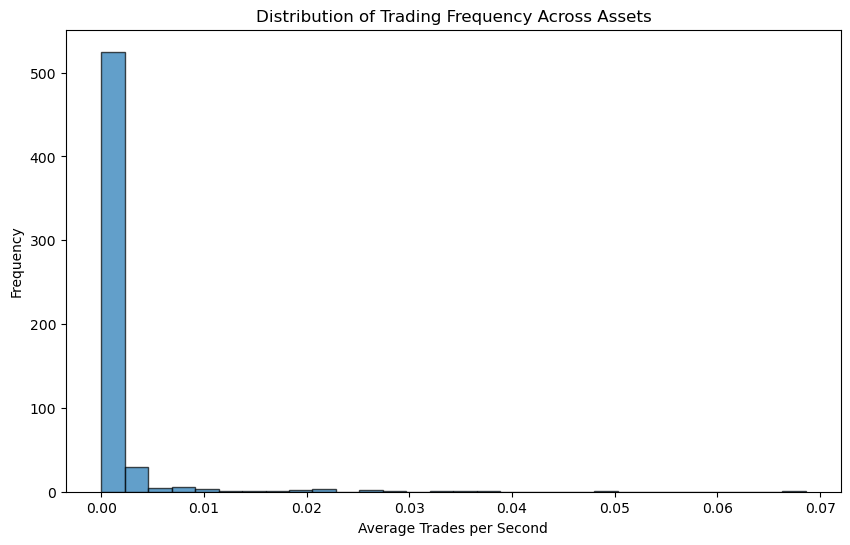

count    5.850000e+02
mean     1.296745e-03
std      5.254958e-03
min      1.280642e-07
25%      6.915468e-06
50%      3.739475e-05
75%      3.310460e-04
max      6.859107e-02
dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])


trading_data['time_diff'] = trading_data['timestamp'].diff().dt.total_seconds()

# Calculate the number of trades per second

# The frequency of trades per second for each asset can be calculated by dividing the number of trades by the total duration in seconds
frequency = trading_data.groupby('symbol').size() / (trading_data['timestamp'].max() - trading_data['timestamp'].min()).total_seconds()


plt.figure(figsize=(10, 6))
plt.hist(frequency, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Average Trades per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Trading Frequency Across Assets')
plt.show()

print(frequency.describe())

In [13]:
# Calculate the total number of trades per symbol
total_trades = trading_data.groupby('symbol').size()

# Calculate the total market hours (assuming the market opens at 9:30 AM and closes at 4:00 PM)
market_start_time = pd.to_datetime('09:30:00')
market_end_time = pd.to_datetime('16:00:00')
market_duration_seconds = (market_end_time - market_start_time).seconds

min_bin_size_seconds = market_duration_seconds / (total_trades / 20)  # Bin size ensuring at least 10 trades

# Check for the minimum bin size that ensures 10-20 trades
min_bin_size_seconds

symbol
10 Year             1.207542
10 Year O1        387.096774
2 Year              1.853282
20 Year             6.084164
20 Year O1       4178.571429
                    ...     
SFE YMU4-YMZ4    1368.421053
SFE YMU4XMU4     1779.467681
SFE YMZ4         3162.162162
SFE YMZ4XMZ4     1966.386555
SGX XUV4         3744.000000
Length: 585, dtype: float64

In [14]:
min_bin_size_seconds.head(20)

symbol
10 Year                     1.207542
10 Year O1                387.096774
2 Year                      1.853282
20 Year                     6.084164
20 Year O1               4178.571429
3 Year                      2.170707
3 Year O1               13764.705882
30 Year                     2.643082
30 Year O1              29250.000000
5 Year                      0.873788
5 Year O1                1376.470588
7 Year                      2.703593
7 Year O1                1966.386555
7 Year O2              234000.000000
CBOT 3YU4                 116.679132
CBOT 3YU4-3YZ4         234000.000000
CBOT 3YZ4                 102.609077
CBOT FF:BF K5-N5-Q5    156000.000000
CBOT FF:BF U4-V4-X4    234000.000000
CBOT FF:BF V4-X4-F5      3416.058394
dtype: float64

In [15]:
import pandas as pd

trading_data['timestamp'] = pd.to_datetime(trading_data['timestamp'])

# 'B' for Buy, 'S' for Sell
trading_data['order_flow'] = trading_data['side'].map({'B': 1, 'S': -1}) * trading_data['quantity']

# Round the timestamp to the nearest 10 seconds for grouping
trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')

# Group by the rounded timestamp and sum the order flows for each 10-second interval
order_flow_aggregated = trading_data.groupby('time_rounded')['order_flow'].sum().reset_index()

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/185544999.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['time_rounded'] = trading_data['timestamp'].dt.floor('10S')


In [16]:
order_flow_aggregated

,time_rounded,order_flow
0,2024-08-02 11:56:30,-17.0
1,2024-08-02 12:03:00,-51.0
2,2024-08-02 12:03:30,-81.0
3,2024-08-02 12:03:40,-23.0
4,2024-08-02 12:33:40,15.0
...,...,...
229171,2024-10-31 20:59:00,-11.0
229172,2024-10-31 20:59:10,-140.0
229173,2024-10-31 20:59:20,4.0
229174,2024-10-31 20:59:30,-20.0


# Mapping Trade and Market Data

The market data is recorded at 10-second intervals, meaning that within each 10-second window, the bid and ask prices are assumed to remain constant. To align the trading data with the corresponding market conditions, we round the executiontime in the trading data to the 10 seconds. This ensures that each trade is matched with the correct bid and ask price available at that time interval.

In [17]:
# Convert execution time to datetime format
trading_data['executiontime'] = pd.to_datetime(trading_data['executiontime'])

# Round execution time down to the nearest 10 seconds
trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/1392569256.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  trading_data['executiontime_10s'] = trading_data['executiontime'].dt.floor('10S')


In [18]:
trading_data[['executiontime', 'symbol', 'executiontime_10s']]

,executiontime,symbol,executiontime_10s
0,2024-09-13 07:15:38.351,SFE XMU4-XMZ4,2024-09-13 07:15:30
1,2024-09-13 07:15:38.360,SFE XMU4-XMZ4,2024-09-13 07:15:30
2,2024-09-13 07:15:39.964,SFE XMU4-XMZ4,2024-09-13 07:15:30
3,2024-09-13 07:15:40.128,SFE XMU4-XMZ4,2024-09-13 07:15:40
4,2024-09-13 07:15:39.963,SFE XMZ4,2024-09-13 07:15:30
...,...,...,...
5923554,2024-10-04 20:59:06.135,5 Year,2024-10-04 20:59:00
5923555,2024-10-04 20:59:06.136,5 Year,2024-10-04 20:59:00
5923556,2024-10-04 20:59:06.136,5 Year,2024-10-04 20:59:00
5923557,2024-10-04 20:59:06.138,5 Year,2024-10-04 20:59:00


Filter a subdataframe with only symbols in ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

In [19]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']

# Filter the trading data to include only rows with the selected maturity symbols
filtered_trading_data = trading_data[trading_data['symbol'].isin(maturity_symbols)]

In [20]:
filtered_trading_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,timestamp,build_id,build_name,hide_duration,pop_ticks,label,time_diff,order_flow,time_rounded,executiontime_10s
79861,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:33.513999872,NaN,None,NaN,None,r8fin_trades,-52006.454,-1.0,2024-09-16 06:32:30,2024-09-16 06:32:30
79862,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:32:57.002000128,NaN,None,NaN,None,r8fin_trades,23.488,-1.0,2024-09-16 06:32:50,2024-09-16 06:32:50
79863,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.095000064,NaN,None,NaN,None,r8fin_trades,4.093,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00
79864,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:33:01.092999936,NaN,None,NaN,None,r8fin_trades,-0.002,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00
79865,2024-09-16,2024-09-16 06:45:16.811,2024-09-16 06:45:16.809,2024-09-16 02:45:16.809,575318.0,7024412361,7024412361,696312881.0,PWLPLFJQ,PWOBVWCE,...,2024-09-16 06:45:16.811000064,NaN,None,NaN,None,r8fin_trades,735.718,-2.0,2024-09-16 06:45:10,2024-09-16 06:45:10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5923554,2024-10-04,2024-10-04 20:59:06.135,2024-10-04 20:59:06.128,2024-10-04 16:59:06.128,590551.0,7029292600,7029291632,699617037.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.135000064,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.000,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923555,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.130,2024-10-04 16:59:06.130,590551.0,7029292601,7029291632,699617036.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.001,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923556,2024-10-04,2024-10-04 20:59:06.136,2024-10-04 20:59:06.131,2024-10-04 16:59:06.131,590551.0,7029292601,7029291632,699617034.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.136000000,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.000,-3.0,2024-10-04 20:59:00,2024-10-04 20:59:00
5923557,2024-10-04,2024-10-04 20:59:06.138,2024-10-04 20:59:06.132,2024-10-04 16:59:06.132,590551.0,7029292602,7029291632,699617033.0,CNKMYOTP,NKHTRYPK,...,2024-10-04 20:59:06.138000128,107983.0,H-AGG,0.0,"comp_0: 1.0, comp_1: 0.0, comp_2: 0.0",r8fin_trades,0.002,-1.0,2024-10-04 20:59:00,2024-10-04 20:59:00


In [21]:
len(filtered_trading_data)

1818376

In [22]:
# Define the list of symbols that are standard maturities and can be mapped to market data
maturity_symbols = ['30 Year', '5 Year', '2 Year', '10 Year', '3 Year', '7 Year', '20 Year']
market_symbols = ['30yr', '5yr', '2yr', '10yr', '3yr', '7yr', '20yr']

# Create a mapping between trading symbols and market symbols
symbol_mapping = dict(zip(maturity_symbols, market_symbols))

# Create an empty list to store merged data for each symbol
merged_data_list = []

# Loop through each symbol and merge with corresponding market data
for maturity_symbol, market_symbol in symbol_mapping.items():
    # Filter trading data for the current symbol
    trading_data_filtered = filtered_trading_data[filtered_trading_data['symbol'] == maturity_symbol]
    market_data_filtered = market_data[market_symbol].copy()

    # Convert market data time to datetime format
    market_data_filtered['time'] = pd.to_datetime(market_data_filtered['time'])

    # Merge trading data with market data based on exact match of time, including bid/ask size and price
    merged_data = pd.merge(trading_data_filtered, market_data_filtered,
                           left_on='executiontime_10s', right_on='time',
                           how='left')

    # Append merged data to the list
    merged_data_list.append(merged_data)

In [23]:
# Concatenate all merged data
mapped_data = pd.concat(merged_data_list, ignore_index=True)

In [24]:
len(mapped_data)

1818376

In [25]:
mapped_data

,trade_date,executiontime,brokerexecutiontime,exec_time_et,recapid,orderid,parentcorrelationorderid,executionid,firm,client,...,label,time_diff,order_flow,time_rounded,executiontime_10s,time,bid_size,bid_price,ask_size,ask_price
0,2024-09-16,2024-09-16 06:32:33.514,2024-09-16 06:32:33.512,2024-09-16 02:32:33.512,575316.0,7024412350,7024412350,696312820.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,-52006.454,-1.0,2024-09-16 06:32:30,2024-09-16 06:32:30,2024-09-16 06:32:30,7.0,104.734375,3.0,104.828125
1,2024-09-16,2024-09-16 06:32:57.002,2024-09-16 06:32:57.002,2024-09-16 02:32:57.002,575316.0,7024412350,7024412350,696312821.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,23.488,-1.0,2024-09-16 06:32:50,2024-09-16 06:32:50,2024-09-16 06:32:50,5.0,104.687500,2.0,104.796875
2,2024-09-16,2024-09-16 06:33:01.095,2024-09-16 06:33:01.093,2024-09-16 02:33:01.093,575316.0,7024412350,7024412350,696312822.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,4.093,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375
3,2024-09-16,2024-09-16 06:33:01.093,2024-09-16 06:33:01.091,2024-09-16 02:33:01.091,575316.0,7024412350,7024412350,696312823.0,PWLPLFJQ,PWOBVWCE,...,r8fin_trades,-0.002,-1.0,2024-09-16 06:33:00,2024-09-16 06:33:00,2024-09-16 06:33:00,2.0,104.750000,6.0,104.859375
4,2024-09-16,2024-09-16 06:43:56.053,2024-09-16 06:43:56.052,2024-09-16 02:43:56.052,575369.0,7024415027,7024411965,696312874.0,UZIZISKH,IPRLWHII,...,r8fin_trades,6.460,1.0,2024-09-16 06:43:50,2024-09-16 06:43:50,2024-09-16 06:43:50,6.0,104.734375,1.0,105.625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1818371,2024-10-04,2024-10-04 20:57:50.936,2024-10-04 20:57:50.934,2024-10-04 16:57:50.934,590546.0,7029292130,7029287470,699616752.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,0.159,1.0,2024-10-04 20:57:50,2024-10-04 20:57:50,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375
1818372,2024-10-04,2024-10-04 20:57:59.989,2024-10-04 20:57:59.987,2024-10-04 16:57:59.987,590546.0,7029292285,7029287470,699616782.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,4.219,1.0,2024-10-04 20:57:50,2024-10-04 20:57:50,2024-10-04 20:57:50,1.0,97.375000,1.0,97.609375
1818373,2024-10-04,2024-10-04 20:58:15.156,2024-10-04 20:58:15.155,2024-10-04 16:58:15.155,590546.0,7029292347,7029287470,699616825.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,0.060,1.0,2024-10-04 20:58:10,2024-10-04 20:58:10,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375
1818374,2024-10-04,2024-10-04 20:58:15.184,2024-10-04 20:58:15.182,2024-10-04 16:58:15.182,590546.0,7029292354,7029287470,699616826.0,FDAUTWEA,JIWMFDHM,...,r8fin_trades,0.028,1.0,2024-10-04 20:58:10,2024-10-04 20:58:10,2024-10-04 20:58:10,1.0,97.375000,1.0,97.609375


In [26]:
mapped_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'time_diff', 'order_flow',
       'time_rounded', 'executiontime_10s', 'time', 'bid_size', 'bid_price',
       'ask_size', 'ask_price'],
      dtype='object')

In [27]:
mapped_data['side']

0          S
1          S
2          S
3          S
4          B
          ..
1818371    B
1818372    B
1818373    B
1818374    B
1818375    B
Name: side, Length: 1818376, dtype: object

In [28]:
mapped_data['side_numeric'] = mapped_data['side'].map({'B': 1, 'S': -1})

mapped_data['signed_quantity'] = mapped_data['side_numeric'] * mapped_data['quantity']

mapped_data['executiontime_10s'] = pd.to_datetime(mapped_data['executiontime_10s'])

grouped = mapped_data.groupby('executiontime_10s')

order_flow = grouped['signed_quantity'].sum()

In [29]:
order_flow

executiontime_10s
2024-08-04 23:44:40   -1.0
2024-08-04 23:44:50   -4.0
2024-08-04 23:45:00   -8.0
2024-08-04 23:45:10   -1.0
2024-08-04 23:45:30   -1.0
                      ... 
2024-10-31 20:59:00    2.0
2024-10-31 20:59:10    7.0
2024-10-31 20:59:20   -3.0
2024-10-31 20:59:30    2.0
2024-10-31 20:59:40   -1.0
Name: signed_quantity, Length: 170307, dtype: float64

In [30]:
def calculate_order_flow(bin_size):
    # Calculate the number of 10-second intervals per bin
    num_bins = bin_size // 10

    # Group by the original 10-second bins and calculate signed order flow
    grouped = mapped_data.groupby('executiontime_10s')
    order_flow_per_bin = grouped['signed_quantity'].sum()

    # Calculate order flow for the specified bin size
    resampled_order_flow = order_flow_per_bin.rolling(window=num_bins).sum().iloc[num_bins - 1::num_bins]

    return resampled_order_flow

In [31]:
calculate_order_flow(10)

executiontime_10s
2024-08-04 23:44:40   -1.0
2024-08-04 23:44:50   -4.0
2024-08-04 23:45:00   -8.0
2024-08-04 23:45:10   -1.0
2024-08-04 23:45:30   -1.0
                      ... 
2024-10-31 20:59:00    2.0
2024-10-31 20:59:10    7.0
2024-10-31 20:59:20   -3.0
2024-10-31 20:59:30    2.0
2024-10-31 20:59:40   -1.0
Name: signed_quantity, Length: 170307, dtype: float64

In [32]:
order_flow = calculate_order_flow(10)

In [33]:
# mid-price for each row
mapped_data['mid_price'] = (mapped_data['bid_price'] + mapped_data['ask_price']) / 2

# Group by the 10-second bins and get the last mid-price of each bin to reflect the price at the end of the bin
mid_price_per_bin = mapped_data.groupby('executiontime_10s')['mid_price'].last()

# Calculate price variation as the difference between consecutive bins
price_variation = mid_price_per_bin.diff()

price_variation

executiontime_10s
2024-08-04 23:44:40         NaN
2024-08-04 23:44:50    0.000000
2024-08-04 23:45:00    0.005859
2024-08-04 23:45:10   -0.003906
2024-08-04 23:45:30    0.016602
                         ...   
2024-10-31 20:59:00         NaN
2024-10-31 20:59:10         NaN
2024-10-31 20:59:20         NaN
2024-10-31 20:59:30         NaN
2024-10-31 20:59:40         NaN
Name: mid_price, Length: 170307, dtype: float64

In [34]:
## Calculate price variation based on different bin size in second

def calculate_price_variation(bin_size):
    # Calculate the number of 10-second intervals per bin
    num_bins = bin_size // 10

    # Calculate mid-price for each row
    mapped_data['mid_price'] = (mapped_data['bid_price'] + mapped_data['ask_price']) / 2

    # Group by the original 10-second bins
    mid_price_per_bin = mapped_data.groupby('executiontime_10s')['mid_price'].last()

    # Shift by num_bins and calculate the difference to determine price variation
    price_variation = mid_price_per_bin.diff(periods=num_bins)

    return price_variation

In [35]:
calculate_price_variation(10)

executiontime_10s
2024-08-04 23:44:40         NaN
2024-08-04 23:44:50    0.000000
2024-08-04 23:45:00    0.005859
2024-08-04 23:45:10   -0.003906
2024-08-04 23:45:30    0.016602
                         ...   
2024-10-31 20:59:00         NaN
2024-10-31 20:59:10         NaN
2024-10-31 20:59:20         NaN
2024-10-31 20:59:30         NaN
2024-10-31 20:59:40         NaN
Name: mid_price, Length: 170307, dtype: float64

In [36]:
price_variation = calculate_price_variation(10)
price_variation

executiontime_10s
2024-08-04 23:44:40         NaN
2024-08-04 23:44:50    0.000000
2024-08-04 23:45:00    0.005859
2024-08-04 23:45:10   -0.003906
2024-08-04 23:45:30    0.016602
                         ...   
2024-10-31 20:59:00         NaN
2024-10-31 20:59:10         NaN
2024-10-31 20:59:20         NaN
2024-10-31 20:59:30         NaN
2024-10-31 20:59:40         NaN
Name: mid_price, Length: 170307, dtype: float64

In [37]:
order_flow_volatility = grouped['signed_quantity'].std()
price_volatility = grouped['mid_price'].std()

In [38]:
order_flow_volatility

executiontime_10s
2024-08-04 23:44:40         NaN
2024-08-04 23:44:50    1.414214
2024-08-04 23:45:00    0.000000
2024-08-04 23:45:10         NaN
2024-08-04 23:45:30         NaN
                         ...   
2024-10-31 20:59:00    0.000000
2024-10-31 20:59:10    1.641609
2024-10-31 20:59:20    0.707107
2024-10-31 20:59:30    0.000000
2024-10-31 20:59:40    1.154701
Name: signed_quantity, Length: 170307, dtype: float64

In [39]:
mapped_data['mid_price'] = (mapped_data['bid_price'] + mapped_data['ask_price']) / 2

mid_price_per_bin = mapped_data.groupby('executiontime_10s')['mid_price'].last().dropna()

# Define a rolling window size, e.g., 10 bins
window_size = 10

# Calculate the rolling standard deviation to estimate volatility
price_volatility = mid_price_per_bin.rolling(window=window_size).std()

print(price_volatility)

executiontime_10s
2024-08-04 23:44:40         NaN
2024-08-04 23:44:50         NaN
2024-08-04 23:45:00         NaN
2024-08-04 23:45:10         NaN
2024-08-04 23:45:30         NaN
                         ...   
2024-10-31 17:29:10    2.718156
2024-10-31 17:29:20    2.588399
2024-10-31 17:29:30    2.405807
2024-10-31 17:29:50    2.352037
2024-10-31 17:30:00    2.352932
Name: mid_price, Length: 166790, dtype: float64


In [40]:
from sklearn.linear_model import LinearRegression

# Combine all metrics into a DataFrame for further calculations
cross_impact_data = pd.DataFrame({
    'order_flow': order_flow,
    'price_variation': price_variation,
    'order_flow_volatility': order_flow_volatility,
    'price_volatility': price_volatility
}).dropna()

# Step 10: Cross impact calculation (linear relationship between price variation and order flow)
# Assuming a simple linear regression for cross-impact calculation

# Prepare data for regression
X = cross_impact_data[['order_flow']].values
y = cross_impact_data['price_variation'].values

# Fit the linear model
model = LinearRegression()
model.fit(X, y)

# Get the cross-impact coefficient (slope of the linear regression)
cross_impact_coefficient = model.coef_[0]
print(f'Cross-Impact Coefficient: {cross_impact_coefficient}')


Cross-Impact Coefficient: 0.00027157147864261325


Price variation matrix seems reasonable.


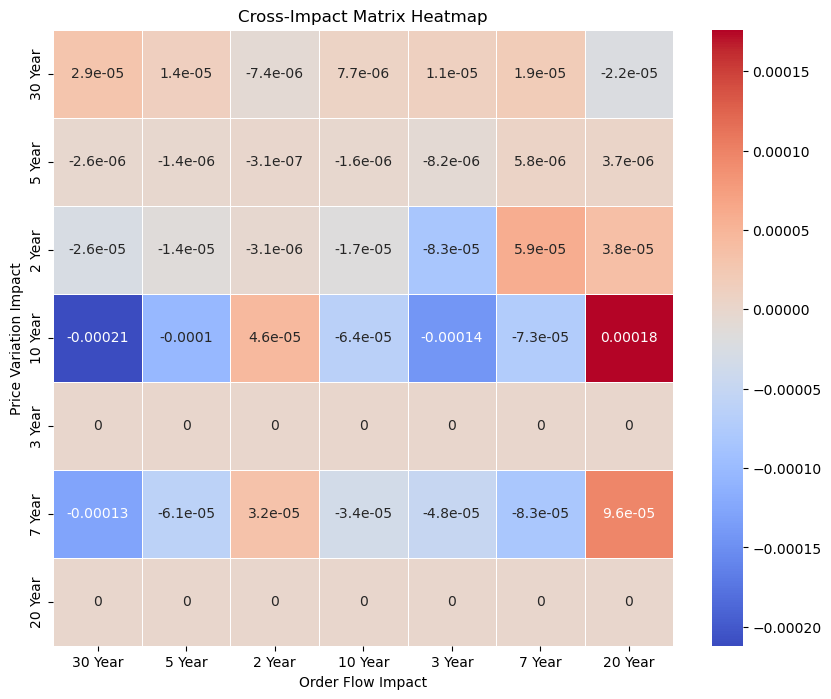

In [41]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate Signed Order Flow
mapped_data['signed_quantity'] = np.where(mapped_data['side'] == 'B', 1, -1) * mapped_data['quantity']

# Step 2: Calculate Mid Price
mapped_data['mid_price'] = (mapped_data['bid_price'] + mapped_data['ask_price']) / 2

# Step 3: Handle Missing Values by Forward Fill
mapped_data['mid_price'] = mapped_data['mid_price'].ffill()

# Step 4: Group Data by execution time bins (`executiontime_10s`) for each symbol
maturity_symbols = mapped_data['symbol'].unique()

# Initialize dictionaries to store order flow and price variation data per symbol
order_flow_data = {}
price_variation_data = {}

# Loop through each symbol to calculate order flow and price variation
for symbol in maturity_symbols:
    # Filter data for the current symbol
    symbol_data = mapped_data[mapped_data['symbol'] == symbol]

    # Calculate order flow per bin for the symbol
    order_flow_data[symbol] = symbol_data.groupby('executiontime_10s')['signed_quantity'].sum()

    # Calculate price variation per bin for the symbol
    price_variation_data[symbol] = symbol_data.groupby('executiontime_10s')['mid_price'].agg(lambda x: x.iloc[-1] - x.iloc[0])

# Create DataFrames for all assets
order_flow_matrix = pd.DataFrame(order_flow_data)
price_variation_matrix = pd.DataFrame(price_variation_data)

# Drop rows with missing values in either DataFrame to ensure consistent lengths
common_index = order_flow_matrix.dropna().index.intersection(price_variation_matrix.dropna().index)

order_flow_matrix = order_flow_matrix.loc[common_index]
price_variation_matrix = price_variation_matrix.loc[common_index]

# Step 5: Check if the price variation matrix still has zeroes
if price_variation_matrix.eq(0).all().all():
    print("Warning: All price variations are zero. Please check data sources or binning approach.")
else:
    print("Price variation matrix seems reasonable.")

# Step 6: Calculate Volatility of Order Flow and Price Variation
order_flow_volatility = order_flow_matrix.std()
price_volatility = price_variation_matrix.std()

# Step 7: Multivariate Linear Regression to Calculate Cross-Impact Matrix
n_assets = len(maturity_symbols)
cross_impact_matrix = np.zeros((n_assets, n_assets))

# Loop through each asset as the dependent variable
for i in range(n_assets):
    # Set the dependent variable (price variation for asset `i`)
    y = price_variation_matrix.iloc[:, i].values

    # Set the independent variables (order flows for all assets)
    X = order_flow_matrix.values

    # Check for length consistency before regression
    if X.shape[0] != len(y):
        print(f"Skipping asset {i} due to inconsistent sample sizes.")
        continue

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Store the coefficients in the cross-impact matrix
    cross_impact_matrix[i, :] = model.coef_

# Convert cross-impact matrix to DataFrame for better visualization
cross_impact_matrix_df = pd.DataFrame(cross_impact_matrix, index=maturity_symbols, columns=maturity_symbols)

# Step 8: Plot the Cross-Impact Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_impact_matrix_df, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Cross-Impact Matrix Heatmap")
plt.xlabel("Order Flow Impact")
plt.ylabel("Price Variation Impact")
plt.show()

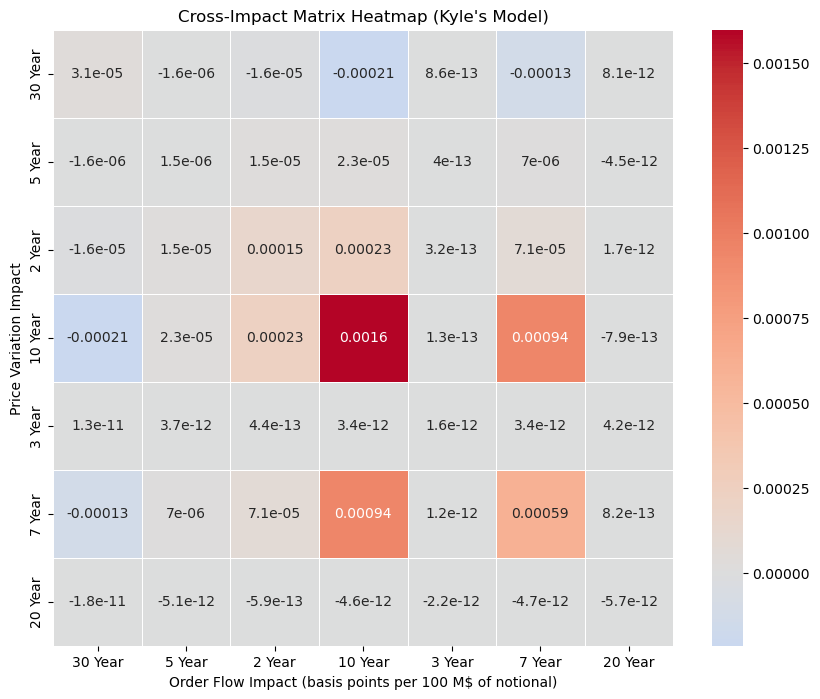

In [42]:
import numpy as np
import pandas as pd
from scipy.linalg import sqrtm, inv
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate Covariance Matrices
# Covariance matrix of price variations (Σ)
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

# Covariance matrix of order flows (Ω)
order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Calculate the Inverse Square Root of Ω
Ω_inv_sqrt = inv(sqrtm(Ω))

# Step 3: Calculate the Kyle Cross-Impact Matrix (Λ)
# Λ_Kyle = Y * (Ω^-1/2)^T * sqrt((Ω^1/2)^T * Σ * Ω^1/2) * Ω^-1/2

# Calculate (Ω^1/2)
Ω_sqrt = sqrtm(Ω)

# Calculate the intermediate product: (Ω^1/2)^T * Σ * Ω^1/2
intermediate_product = Ω_sqrt.T @ Σ @ Ω_sqrt

# Calculate the square root of the intermediate product
sqrt_intermediate_product = sqrtm(intermediate_product)

# Finally, compute the Kyle Cross-Impact Matrix (Λ)
Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt

# Step to Convert Complex to Real Values
# Explicitly take only the real part of Λ_Kyle to avoid issues during plotting
Λ_Kyle_real = np.real(Λ_Kyle)

# Convert Λ_Kyle to DataFrame for better visualization
cross_impact_matrix_df = pd.DataFrame(Λ_Kyle_real, index=common_index, columns=common_index)

# Step 4: Plot the Cross-Impact Matrix as a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_impact_matrix_df, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Cross-Impact Matrix Heatmap (Kyle's Model)")
plt.xlabel("Order Flow Impact (basis points per 100 M$ of notional)")
plt.ylabel("Price Variation Impact")
plt.show()

In [43]:
mapped_data['timestamp']

0         2024-09-16 06:32:33.513999872
1         2024-09-16 06:32:57.002000128
2         2024-09-16 06:33:01.095000064
3         2024-09-16 06:33:01.092999936
4         2024-09-16 06:43:56.052999936
                       ...             
1818371   2024-10-04 20:57:50.936000000
1818372   2024-10-04 20:57:59.989000192
1818373   2024-10-04 20:58:15.156000000
1818374   2024-10-04 20:58:15.184000000
1818375   2024-10-04 20:58:15.210000128
Name: timestamp, Length: 1818376, dtype: datetime64[ns]

In [44]:
mapped_data['timestamp'] = pd.to_datetime(mapped_data['timestamp'])

# Create a 'order_flow' column as you did earlier
mapped_data['order_flow'] = mapped_data['side'].map({'B': 1, 'S': -1}) * mapped_data['quantity']

instant_data = mapped_data[['timestamp', 'order_flow']]

# time iinterval
time_intervals = ['0S','10S', '30S', '60S', '1H','12H']

# Round the timestamp to the nearest time interval and group by it
for interval in time_intervals:
    mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)  # Round to nearest interval
    aggregated_data = mapped_data.groupby('time_rounded')['order_flow'].sum().reset_index()
    print(f"Order flow aggregated by {interval}:")
    print(aggregated_data.head())

# 3. EOD (End of Day)
# Group by the date (ignoring time) and aggregate order flow for each day
mapped_data['date'] = mapped_data['timestamp'].dt.date  # Extract date part
eod_data = mapped_data.groupby('date')['order_flow'].sum().reset_index()
print("Order flow aggregated by End of Day (EOD):")
print(eod_data.head())

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2400331510.py:13: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)  # Round to nearest interval


Order flow aggregated by 0S:
                   time_rounded  order_flow
0 2024-08-04 23:44:45.729000192        -1.0
1 2024-08-04 23:44:50.007000064        -1.0
2 2024-08-04 23:44:50.504000000        -3.0
3 2024-08-04 23:45:06.188000000        -1.0
4 2024-08-04 23:45:06.201999872        -1.0
Order flow aggregated by 10S:
         time_rounded  order_flow
0 2024-08-04 23:44:40        -1.0
1 2024-08-04 23:44:50        -4.0
2 2024-08-04 23:45:00        -8.0
3 2024-08-04 23:45:10        -1.0
4 2024-08-04 23:45:30        -1.0
Order flow aggregated by 30S:
         time_rounded  order_flow
0 2024-08-04 23:44:30        -5.0
1 2024-08-04 23:45:00        -9.0
2 2024-08-04 23:45:30        -1.0
3 2024-08-04 23:51:00        -3.0
4 2024-08-04 23:52:00         0.0
Order flow aggregated by 60S:
         time_rounded  order_flow
0 2024-08-04 23:44:00        -5.0
1 2024-08-04 23:45:00       -10.0
2 2024-08-04 23:51:00        -3.0
3 2024-08-04 23:52:00         0.0
4 2024-08-04 23:53:00        -4.0
Order

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2400331510.py:13: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)  # Round to nearest interval
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2400331510.py:13: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)  # Round to nearest interval
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2400331510.py:13: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)  # Round to nearest interval
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2400331510.py:13: FutureWarning: 'H' is deprecated and will be removed in a f

Order flow aggregated by End of Day (EOD):
         date  order_flow
0  2024-08-04       -22.0
1  2024-08-05      2423.0
2  2024-08-06      3342.0
3  2024-08-07      7380.0
4  2024-08-08      5447.0


In [45]:
# Outlier markout
def calculate_markout(row, future_mid_yield=None):
    if row['side'] == 'B':  # Buy
        # Buy Markout formula: Compare trade price with mid yield
        return row['mid_price'] - row['price']
    elif row['side'] == 'S':  # Sell
        # Sell Markout formula: Compare future mid price (at future timestamp) with trade price
        return row['price'] - row['mid_price']

mapped_data['markout'] = mapped_data.apply(calculate_markout, axis=1)

In [46]:
mean_markout = mapped_data['markout'].mean()
std_markout = mapped_data['markout'].std()

# Add a column for Z-scores
mapped_data['z_score'] = (mapped_data['markout'] - mean_markout) / std_markout

# Define outlier threshold (e.g., Z-score > 3 or < -3)
threshold = 4
mapped_data['is_outlier_z'] = np.abs(mapped_data['z_score']) > threshold

# Extract outliers
z_outliers = mapped_data[mapped_data['is_outlier_z']]

In [47]:
z_outliers.shape[0]

11503

In [48]:
mapped_data.columns

Index(['trade_date', 'executiontime', 'brokerexecutiontime', 'exec_time_et',
       'recapid', 'orderid', 'parentcorrelationorderid', 'executionid', 'firm',
       'client', 'syntheticcontractidentifier', 'instrument',
       'syntheticpricemode', 'syntheticticksize',
       'syntheticcontractdefinition', 'security_type', 'symbol', 'cusip',
       'side', 'quantity', 'price', 'order_source', 'broker_id', 'exchange',
       'exchange_route', 'exchange_endoint', 'exchange_lp', 'is_aggressive',
       'destination', 'order_text', 'quote_or_hedge', 'hedge_target_price',
       'cash_exchange_trade_id', 'timestamp', 'build_id', 'build_name',
       'hide_duration', 'pop_ticks', 'label', 'time_diff', 'order_flow',
       'time_rounded', 'executiontime_10s', 'time', 'bid_size', 'bid_price',
       'ask_size', 'ask_price', 'side_numeric', 'signed_quantity', 'mid_price',
       'date', 'markout', 'z_score', 'is_outlier_z'],
      dtype='object')

In [49]:
time_interval_dataframes = {}

for interval in time_intervals:
    # Round timestamps to the current time interval
    mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)

    # Group by LP and time interval
    aggregated_data = mapped_data.groupby(['exchange_lp', 'time_rounded']).agg(
        total_market_value=('quantity', 'sum'),
        avg_markout=('markout', 'mean'),
        trade_count=('signed_quantity', 'count'),
        side=('side', 'first'),  # Assuming the side is consistent within the group
        price=('price', 'first'),
        mid_price = ('mid_price', 'first')
    ).reset_index()

    # Store the resulting DataFrame in the dictionary
    time_interval_dataframes[interval] = aggregated_data

# Access each DataFrame by its time interval
df_instant = time_interval_dataframes['0S']
df_10s = time_interval_dataframes['10S']
df_30s = time_interval_dataframes['30S']
df_60s = time_interval_dataframes['60S']
df_1h = time_interval_dataframes['1H']
df_12h = time_interval_dataframes['12H']

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2217278859.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2217278859.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2217278859.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timestamp'].dt.floor(interval)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/2217278859.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  mapped_data['time_rounded'] = mapped_data['timesta

In [50]:
def detect_outliers_by_z_score(df, markout_column='markout', z_threshold=4):
    """
    Detect outliers in a DataFrame using Z-scores.

    Parameters:
        df (pd.DataFrame): The input DataFrame.
        markout_column (str): The column containing markout values.
        z_threshold (float): The Z-score threshold for defining outliers.

    Returns:
        pd.DataFrame: A DataFrame containing only the outliers.
        pd.DataFrame: The original DataFrame with outlier flags added.
    """
    # Calculate mean and standard deviation of the markout column
    mean_markout = df[markout_column].mean()
    std_markout = df[markout_column].std()

    # Add a column for Z-scores
    df['z_score'] = (df[markout_column] - mean_markout) / std_markout

    # Identify outliers based on the Z-score threshold
    df['is_outlier_z'] = np.abs(df['z_score']) > z_threshold

    # Extract rows that are outliers
    outliers = df[df['is_outlier_z']]

    return outliers, df


In [51]:
df_instant['markout'] = df_instant.apply(calculate_markout, axis=1)
df_10s['markout'] = df_10s.apply(calculate_markout, axis=1)
df_30s['markout'] = df_30s.apply(calculate_markout, axis=1)
df_60s['markout'] = df_60s.apply(calculate_markout, axis=1)
df_1h['markout'] = df_1h.apply(calculate_markout, axis=1)
df_12h['markout'] = df_12h.apply(calculate_markout, axis=1)

In [52]:
df_instant['markout']

0         -0.744141
1          1.578125
2          1.582031
3          0.451172
4          0.451172
             ...   
1468784    0.003906
1468785    0.023438
1468786    0.230469
1468787    0.226562
1468788    0.033203
Name: markout, Length: 1468789, dtype: float64

In [53]:
df_10s_markout_outlier = detect_outliers_by_z_score(df_10s, markout_column = 'markout', z_threshold=4)
num_outliers_10s = df_10s[df_10s['is_outlier_z']].shape[0]
num_outliers_10s

2872

In [54]:
# Detect outliers for each time interval and count the number of outliers
def count_outliers(df, markout_column='markout', z_threshold=4):
    outliers, updated_df = detect_outliers_by_z_score(df, markout_column, z_threshold)
    return outliers.shape[0]  # Number of outliers

# Apply the function to each DataFrame
num_outliers_instant = count_outliers(df_instant, 'markout', z_threshold=4)
num_outliers_10s = count_outliers(df_10s, 'markout', z_threshold=4)
num_outliers_30s = count_outliers(df_30s, 'markout', z_threshold=4)
num_outliers_60s = count_outliers(df_60s, 'markout', z_threshold=4)
num_outliers_1h = count_outliers(df_1h, 'markout', z_threshold=4)
num_outliers_12h = count_outliers(df_12h, 'markout', z_threshold=4)

outlier_summary = {
    'Time Interval': ['0s','10s', '30s', '60s', '1h','12h'],
    'Number of Outliers': [num_outliers_instant,num_outliers_10s, num_outliers_30s, num_outliers_60s, num_outliers_1h,num_outliers_12h]
}

outlier_table = pd.DataFrame(outlier_summary)

# Display the table
print(outlier_table)

  Time Interval  Number of Outliers
0            0s                9094
1           10s                2872
2           30s                2007
3           60s                1504
4            1h                  68
5           12h                  10


In [55]:
df_10s.columns

Index(['exchange_lp', 'time_rounded', 'total_market_value', 'avg_markout',
       'trade_count', 'side', 'price', 'mid_price', 'markout', 'z_score',
       'is_outlier_z'],
      dtype='object')

In [56]:
import pandas as pd

# Function to count outliers per LP
def count_outliers_per_lp(df, outlier_column='is_outlier_z', lp_column='exchange_lp'):
    # Filter out rows with outliers (where is_outlier_z is True)
    outlier_data = df[df[outlier_column] == True]

    # Count outliers for each LP (DEALER)
    lp_outlier_counts = outlier_data[lp_column].value_counts().reset_index()
    lp_outlier_counts.columns = ['Unique LP Identifier', 'Outlier Count']

    return lp_outlier_counts

# Apply this function to each of your dataframes
top_lps_instant = count_outliers_per_lp(df_instant, 'is_outlier_z', 'exchange_lp')
top_lps_10s = count_outliers_per_lp(df_10s, 'is_outlier_z', 'exchange_lp')
top_lps_30s = count_outliers_per_lp(df_30s, 'is_outlier_z', 'exchange_lp')
top_lps_60s = count_outliers_per_lp(df_60s, 'is_outlier_z', 'exchange_lp')
top_lps_1h = count_outliers_per_lp(df_1h, 'is_outlier_z', 'exchange_lp')
top_lps_12h = count_outliers_per_lp(df_12h, 'is_outlier_z', 'exchange_lp')

# Combine results from all time intervals
all_top_lps = pd.concat([top_lps_instant, top_lps_10s, top_lps_30s, top_lps_60s, top_lps_1h, top_lps_12h])

# Aggregate counts across all intervals and get top 5 LPs
top_5_lps = all_top_lps.groupby('Unique LP Identifier')['Outlier Count'].sum().reset_index()
top_5_lps_sorted = top_5_lps.sort_values(by='Outlier Count', ascending=False).head(5)

# Display the top 5 LPs table
print(top_5_lps_sorted)
top_5_lps_sorted.to_csv('top_5_lps_sorted.csv',index = False)

   Unique LP Identifier  Outlier Count
14             WKWSDLYV           5027
13             SBUWHHFR           1875
9              OQFTYCMP           1335
7              MGOHMQGV           1183
10             QIHUJGGL           1152


In [57]:
# Top LPs for Instant Interval
top_lps_instant_sorted = top_lps_instant.sort_values(by='Outlier Count', ascending=False).head(5)
print("Top 5 LPs for Instant Interval:")
print(top_lps_instant_sorted)

# Top LPs for 10s Interval
top_lps_10s_sorted = top_lps_10s.sort_values(by='Outlier Count', ascending=False).head(5)
print("\nTop 5 LPs for 10s Interval:")
print(top_lps_10s_sorted)

# Top LPs for 30s Interval
top_lps_30s_sorted = top_lps_30s.sort_values(by='Outlier Count', ascending=False).head(5)
print("\nTop 5 LPs for 30s Interval:")
print(top_lps_30s_sorted)

# Top LPs for 60s Interval
top_lps_60s_sorted = top_lps_60s.sort_values(by='Outlier Count', ascending=False).head(5)
print("\nTop 5 LPs for 60s Interval:")
print(top_lps_60s_sorted)

# Top LPs for 1h Interval
top_lps_1h_sorted = top_lps_1h.sort_values(by='Outlier Count', ascending=False).head(5)
print("\nTop 5 LPs for 1h Interval:")
print(top_lps_1h_sorted)

# Top LPs for 12h Interval
top_lps_12h_sorted = top_lps_12h.sort_values(by='Outlier Count', ascending=False).head(5)
print("\nTop 5 LPs for 12h Interval:")
print(top_lps_12h_sorted)


Top 5 LPs for Instant Interval:
  Unique LP Identifier  Outlier Count
0             WKWSDLYV           3407
1             SBUWHHFR           1212
2             OQFTYCMP            714
3             MGOHMQGV            685
4             QIHUJGGL            574

Top 5 LPs for 10s Interval:
  Unique LP Identifier  Outlier Count
0             WKWSDLYV            816
1             SBUWHHFR            295
2             QIHUJGGL            282
3             OQFTYCMP            266
4             MGOHMQGV            242

Top 5 LPs for 30s Interval:
  Unique LP Identifier  Outlier Count
0             WKWSDLYV            493
1             SBUWHHFR            206
2             OQFTYCMP            196
3             QIHUJGGL            179
4             MGOHMQGV            154

Top 5 LPs for 60s Interval:
  Unique LP Identifier  Outlier Count
0             WKWSDLYV            307
1             SBUWHHFR            156
2             OQFTYCMP            155
3             QIHUJGGL            114
4      

In [58]:
top_lps_instant_sorted.to_csv('top_lps_instant.csv', index=False)
top_lps_10s_sorted.to_csv('top_lps_10s.csv', index=False)
top_lps_30s_sorted.to_csv('top_lps_30s.csv', index=False)
top_lps_60s_sorted.to_csv('top_lps_60s.csv', index=False)
top_lps_1h_sorted.to_csv('top_lps_1h.csv', index=False)
top_lps_12h_sorted.to_csv('top_lps_12h.csv', index=False)

Selected Pairs and Cross-Impact Coefficients:
     Asset1   Asset2  CrossImpact1_on_2  CrossImpact2_on_1
0   30 Year  10 Year       6.886570e-07       3.482151e-05
1    5 Year  10 Year      -1.317592e-06      -1.755541e-06
2    2 Year   3 Year      -9.052553e-05      -4.487677e-06
3   10 Year  20 Year       2.083826e-04       3.840898e-05
4    3 Year   7 Year       0.000000e+00       0.000000e+00
5   30 Year   2 Year      -8.173598e-06       2.767719e-05
6   30 Year  20 Year      -1.427667e-05       3.258956e-05
7    5 Year   7 Year       8.532544e-06      -9.138621e-07
8   10 Year   7 Year       5.392683e-06       2.342491e-05
9   10 Year   3 Year      -1.493389e-04       6.298338e-06
10  30 Year   5 Year       1.004643e-05       3.462901e-05
11  30 Year   7 Year       1.121112e-05       3.430237e-05
12   5 Year   3 Year      -8.761078e-06      -1.512307e-06
13   2 Year  10 Year      -5.211932e-06       1.144376e-05
14   2 Year  20 Year       5.583270e-05       1.138882e-05
15   2 Yea

/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/442169718.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/442169718.py:51: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  heatmap_data = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)
/var/folders/5w/5g

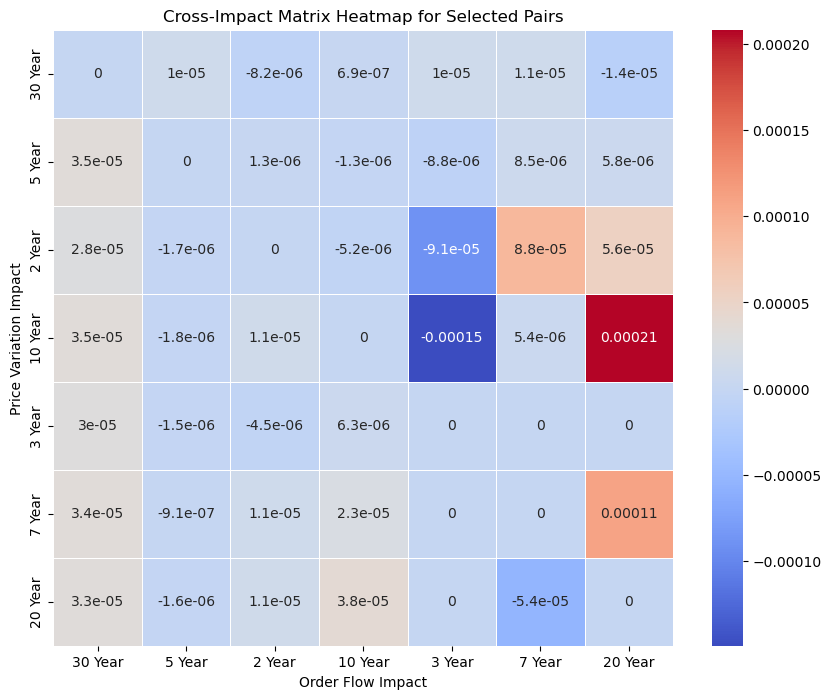

In [59]:
# Step 1: Calculate Correlation Matrix for Order Flow
correlation_matrix = order_flow_matrix.corr()

# Step 2: Extract Unique Pairs with Correlations
correlation_pairs = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
correlation_pairs = correlation_pairs.stack().reset_index()
correlation_pairs.columns = ['Asset1', 'Asset2', 'Correlation']

# Step 3: Create Equal-Sized Buckets for Correlations
num_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], num_buckets, labels=False)

# Step 4: Select Random Pair from Each Bucket
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(1)).reset_index(drop=True)

# Step 5: Perform Cross-Impact Analysis for Selected Pairs
selected_cross_impact = []

for _, row in selected_pairs.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']

    # Prepare data for regression
    y = price_variation_matrix[asset1].values
    X = order_flow_matrix[[asset1, asset2]].values

    # Ensure dimensions match
    if len(y) != X.shape[0]:
        print(f"Skipping pair ({asset1}, {asset2}) due to size mismatch.")
        continue

    # Fit the Linear Regression Model
    model = LinearRegression()
    model.fit(X, y)

    # Save the results
    selected_cross_impact.append({
        'Asset1': asset1,
        'Asset2': asset2,
        'CrossImpact1_on_2': model.coef_[1],
        'CrossImpact2_on_1': model.coef_[0]
    })

# Convert to DataFrame for further analysis
selected_cross_impact_df = pd.DataFrame(selected_cross_impact)

# Step 6: Visualize Results
print("Selected Pairs and Cross-Impact Coefficients:")
print(selected_cross_impact_df)

# Optional: Heatmap of Cross-Impact for Selected Pairs
heatmap_data = pd.DataFrame(index=order_flow_matrix.columns, columns=order_flow_matrix.columns).fillna(0)

for _, row in selected_cross_impact_df.iterrows():
    asset1, asset2 = row['Asset1'], row['Asset2']
    heatmap_data.loc[asset1, asset2] = row['CrossImpact1_on_2']
    heatmap_data.loc[asset2, asset1] = row['CrossImpact2_on_1']

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap="coolwarm", linewidths=0.5, annot=True)  # Enable annotations
plt.title("Cross-Impact Matrix Heatmap for Selected Pairs")
plt.xlabel("Order Flow Impact")
plt.ylabel("Price Variation Impact")
plt.show()


/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/1964967335.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)
/var/folders/5w/5gvvhgf511q4cm8wmw9m68nr0000gn/T/ipykernel_65320/1964967335.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)


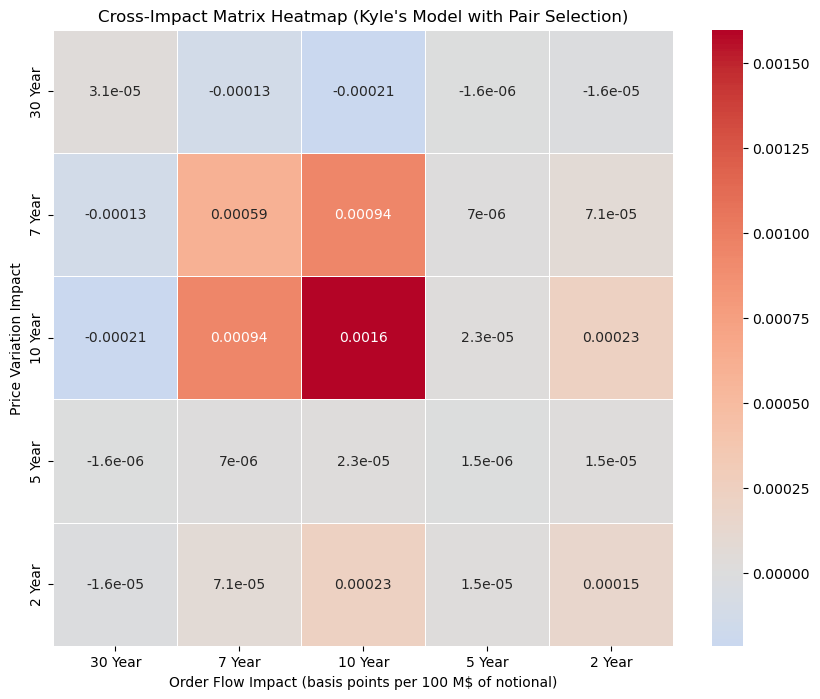

In [60]:
# Step 1: Calculate Covariance Matrices
price_variation_matrix = price_variation_matrix.dropna()  # Drop NaNs
Σ = price_variation_matrix.cov()

order_flow_matrix = order_flow_matrix.dropna()  # Drop NaNs
Ω = order_flow_matrix.cov()

# Ensure matrices have consistent dimensions
common_index = Σ.index.intersection(Ω.index)
Σ = Σ.loc[common_index, common_index]
Ω = Ω.loc[common_index, common_index]

# Step 2: Pair Selection Based on Correlation Buckets
correlation_matrix = price_variation_matrix.corr()

# Flatten correlation matrix to get pairs
correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ['Asset 1', 'Asset 2', 'Correlation']

# Remove self-pairs and duplicates
correlation_pairs = correlation_pairs[correlation_pairs['Asset 1'] != correlation_pairs['Asset 2']]
correlation_pairs = correlation_pairs.drop_duplicates(subset=['Correlation'])

# Define correlation buckets (e.g., 50 buckets)
n_buckets = 50
correlation_pairs['Bucket'] = pd.qcut(correlation_pairs['Correlation'], q=n_buckets, duplicates='drop')

# Select a fixed number of pairs from each bucket (e.g., 20 pairs per bucket)
selected_pairs = correlation_pairs.groupby('Bucket').apply(lambda x: x.sample(n=min(len(x), 30))).reset_index(drop=True)

# Filter covariance matrices for selected pairs
selected_assets = pd.unique(selected_pairs[['Asset 1', 'Asset 2']].values.ravel())
Σ = Σ.loc[selected_assets, selected_assets]
Ω = Ω.loc[selected_assets, selected_assets]

# Step 3: Kyle Cross-Impact Matrix Calculation
Ω_inv_sqrt = inv(sqrtm(Ω))
Ω_sqrt = sqrtm(Ω)

# Intermediate product: (Ω^1/2)^T * Σ * Ω^1/2
intermediate_product = Ω_sqrt.T @ Σ @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)

# Calculate the Kyle Cross-Impact Matrix (Λ)
Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt
Λ_Kyle_real = np.real(Λ_Kyle)  # Take the real part to avoid complex values

# Convert to DataFrame for visualization
cross_impact_matrix_df = pd.DataFrame(Λ_Kyle_real, index=selected_assets, columns=selected_assets)

# Step 4: Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cross_impact_matrix_df, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Cross-Impact Matrix Heatmap (Kyle's Model with Pair Selection)")
plt.xlabel("Order Flow Impact (basis points per 100 M$ of notional)")
plt.ylabel("Price Variation Impact")
plt.show()


In [61]:
from sklearn.metrics import r2_score
split_point = int(len(price_variation_matrix) * (2.5 / 3))
price_variation_in_sample = price_variation_matrix.iloc[:split_point]
order_flow_in_sample = order_flow_matrix.iloc[:split_point]

price_variation_out_sample = price_variation_matrix.iloc[split_point:]
order_flow_out_sample = order_flow_matrix.iloc[split_point:]

Σ_in_sample = price_variation_in_sample.cov()
Ω_in_sample = order_flow_in_sample.cov()

common_index = Σ_in_sample.index.intersection(Ω_in_sample.index)
Σ_in_sample = Σ_in_sample.loc[common_index, common_index]
Ω_in_sample = Ω_in_sample.loc[common_index, common_index]

# Kyle Model computation
Ω_inv_sqrt = inv(sqrtm(Ω_in_sample))
Ω_sqrt = sqrtm(Ω_in_sample)

intermediate_product = Ω_sqrt.T @ Σ_in_sample @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)

Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt

# Predicted price variations = Λ_Kyle * Order Flow
predicted_price_variations = order_flow_out_sample.values @ Λ_Kyle
actual_price_variations = price_variation_out_sample.values



In [62]:
r2_score(actual_price_variations, predicted_price_variations)

0.2527462222698532

In [63]:
from sklearn.metrics import r2_score
import numpy as np
from scipy.linalg import sqrtm, inv

split_point = int(len(price_variation_matrix) * (2.5 / 3))
price_variation_in_sample = price_variation_matrix.iloc[:split_point]
order_flow_in_sample = order_flow_matrix.iloc[:split_point]

price_variation_out_sample = price_variation_matrix.iloc[split_point:]
order_flow_out_sample = order_flow_matrix.iloc[split_point:]

Σ_in_sample = price_variation_in_sample.cov()
Ω_in_sample = order_flow_in_sample.cov()

common_index = Σ_in_sample.index.intersection(Ω_in_sample.index)
Σ_in_sample = Σ_in_sample.loc[common_index, common_index]
Ω_in_sample = Ω_in_sample.loc[common_index, common_index]

# Kyle Model computation
Ω_inv_sqrt = inv(sqrtm(Ω_in_sample))
Ω_sqrt = sqrtm(Ω_in_sample)

intermediate_product = Ω_sqrt.T @ Σ_in_sample @ Ω_sqrt
sqrt_intermediate_product = sqrtm(intermediate_product)

Λ_Kyle = Ω_inv_sqrt.T @ sqrt_intermediate_product @ Ω_inv_sqrt

# Predicted price variations = Λ_Kyle * Order Flow
predicted_price_variations = order_flow_out_sample.values @ Λ_Kyle
actual_price_variations = price_variation_out_sample.values

# Check dimensions of actual_price_variations and predicted_price_variations
print(f"Shape of actual_price_variations: {actual_price_variations.shape}")
print(f"Shape of predicted_price_variations: {predicted_price_variations.shape}")

# Define M (e.g., the inverse of the covariance matrix of price changes)
# Ensure M is of the correct size (5x5)
M = np.linalg.inv(np.diag(np.var(actual_price_variations, axis=0)))

# Compute the residuals (Δpt - predicted Δpt)
residuals = actual_price_variations - predicted_price_variations

# Ensure dimensional consistency by transposing the residuals matrix
residuals_transposed = residuals.T  # Now residuals will have shape (5, N)

# Check dimensions of residuals and M
print(f"Shape of residuals: {residuals.shape}")
print(f"Shape of M: {M.shape}")

# Calculate the numerator (weighted residuals)
numerator = np.sum(np.diagonal(residuals_transposed @ M @ residuals), axis=0)

# Calculate the denominator (weighted actual price changes)
denominator = np.sum(np.diagonal(actual_price_variations.T @ M @ actual_price_variations), axis=0)

# Calculate R^2(M)
r2_M = 1 - (numerator / denominator)

print(f"R^2 for the Kyle Model (M-weighted): {r2_M:.4f}")


Shape of actual_price_variations: (33, 7)
Shape of predicted_price_variations: (33, 7)


LinAlgError: Singular matrix